# Exercise 8.3a solution

We now solve the ODE:

$$
C_{\mathrm{m}}\frac{\mathrm{d}V}{\mathrm{d}t} = -g_{\mathrm{Na}} (V - E_{\mathrm{Na}}) - g_{\mathrm{K}} (V - E_{\mathrm{K}})
$$

With a time-dependent sodium conductance:

$$
g_{\mathrm{Na}}(t) = \begin{cases}
0.55 \text{ µS} & \text{if } 2 \text{ ms} < t < 2.2 \text{ ms}, \\
0.003 \text{ µS} & \text{otherwise.}
\end{cases}
$$


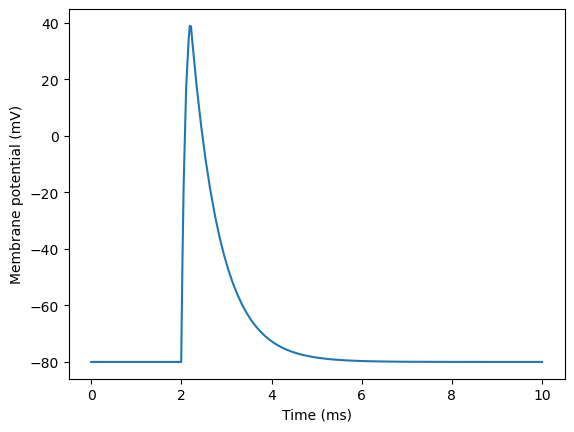

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp


# Define the ODE
def rhs(t, V, Cm, g_K, E_Na, E_K):
    # Piecewise sodium conductance
    g_Na = 0.55 if (2 < t < 2.2) else 0.003

    dV_dt = (-g_Na * (V - E_Na) - g_K * (V - E_K)) / Cm
    return dV_dt


# Define the parameters and initial condition
T = (0, 10)
Cm = 0.05  # nF
g_K = 0.075  # µS

# Nernst potentials (from previous exercises)
E_Na = 70.0  # mV
E_K = -86.0  # mV

params = (Cm, g_K, E_Na, E_K)
y0 = (-80,)  # mV

# Solve the ODE (max_step is crucial here to not skip over the 0.2 ms opening!)
solution = solve_ivp(rhs, T, y0, args=params, max_step=0.1)

t = solution.t
(V,) = solution.y

plt.plot(t, V)
plt.xlabel("Time (ms)")
plt.ylabel("Membrane potential (mV)")
plt.show()